<a href="https://colab.research.google.com/github/Droc-sid/Droc-sid/blob/main/Statistical%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics & Data Analysis Assignment
## Questions 1, 2, and 3 — Complete Solutions

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import f_oneway, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
# QUESTION ONE
## Sales Analytics and Statistical Modelling Dataset

In [2]:
# --- Dataset ---
q1_data = pd.DataFrame({
    'ID':       ['F001','F002','F003','F004','F005','F006','F007'],
    'Sales':    [10, 12, 14, 17, 20, 16, 18],
    'Profit':   [4,  6,  5,  9,  7,  6,  8],
    'Cost':     [7,  9, 10, 12, 11, 10, 13],
    'AdsSpend': [2,  3,  4,  5,  6,  4,  5],
    'Discount': [0.05, 0.10, 0.08, 0.12, 0.07, 0.09, 0.11],
    'Region':   ['East','West','North','South','East','West','North']
})

print('Q1 Dataset:')
print(q1_data.to_string(index=False))

Q1 Dataset:
  ID  Sales  Profit  Cost  AdsSpend  Discount Region
F001     10       4     7         2      0.05   East
F002     12       6     9         3      0.10   West
F003     14       5    10         4      0.08  North
F004     17       9    12         5      0.12  South
F005     20       7    11         6      0.07   East
F006     16       6    10         4      0.09   West
F007     18       8    13         5      0.11  North


### (a) Descriptive Statistics

In [3]:
# Numeric columns only
numeric_cols = ['Sales', 'Profit', 'Cost', 'AdsSpend', 'Discount']
df_num = q1_data[numeric_cols]

desc = df_num.describe().T
desc['median']   = df_num.median()
desc['variance'] = df_num.var(ddof=1)
desc['skewness'] = df_num.skew()
desc['kurtosis'] = df_num.kurtosis()

print('=== Descriptive Statistics ===')
print(desc[['count','mean','median','std','variance','min','max','skewness','kurtosis']].round(4))

print('\n--- Interpretation ---')
for col in numeric_cols:
    mean_v = df_num[col].mean()
    med_v  = df_num[col].median()
    std_v  = df_num[col].std(ddof=1)
    skew_v = df_num[col].skew()
    direction = 'right (positive)' if skew_v > 0 else 'left (negative)'
    print(f'\n{col}: Mean={mean_v:.3f}, Median={med_v:.3f}, Std={std_v:.3f}, Skew={skew_v:.3f} → {direction} skewed')

=== Descriptive Statistics ===
          count     mean  median     std  variance    min    max  skewness  \
Sales       7.0  15.2857   16.00  3.4983   12.2381  10.00  20.00   -0.3003   
Profit      7.0   6.4286    6.00  1.7182    2.9524   4.00   9.00    0.1690   
Cost        7.0  10.2857   10.00  1.9760    3.9048   7.00  13.00   -0.3703   
AdsSpend    7.0   4.1429    4.00  1.3452    1.8095   2.00   6.00   -0.3521   
Discount    7.0   0.0886    0.09  0.0241    0.0006   0.05   0.12   -0.3673   

          kurtosis  
Sales      -0.8603  
Profit     -0.6381  
Cost        0.1849  
AdsSpend   -0.3025  
Discount   -0.5034  

--- Interpretation ---

Sales: Mean=15.286, Median=16.000, Std=3.498, Skew=-0.300 → left (negative) skewed

Profit: Mean=6.429, Median=6.000, Std=1.718, Skew=0.169 → right (positive) skewed

Cost: Mean=10.286, Median=10.000, Std=1.976, Skew=-0.370 → left (negative) skewed

AdsSpend: Mean=4.143, Median=4.000, Std=1.345, Skew=-0.352 → left (negative) skewed

Discount: Mean

### (b) Data Integrity and Statistical Consistency

In [4]:
print('=== Data Integrity Checks ===')

# 1. Missing values
print('\n1. Missing Values:')
print(q1_data.isnull().sum())

# 2. Duplicate rows
print(f'\n2. Duplicate Rows: {q1_data.duplicated().sum()}')

# 3. Logical consistency: Profit should be less than Sales
print('\n3. Logical Check — Profit < Sales?')
check = q1_data['Profit'] < q1_data['Sales']
print(pd.DataFrame({'ID': q1_data['ID'], 'Sales': q1_data['Sales'], 'Profit': q1_data['Profit'], 'Profit<Sales': check}))

# 4. Discount in valid range [0, 1]
print('\n4. Discount range valid [0,1]?')
print(f"   Min={q1_data['Discount'].min()}, Max={q1_data['Discount'].max()} → {(q1_data['Discount'].between(0,1)).all()}")

# 5. Z-score outlier detection
print('\n5. Outlier Detection (|Z| > 2):')
z_scores = np.abs(stats.zscore(df_num))
outliers = (z_scores > 2)
if outliers.any().any():
    print(outliers[outliers.any(axis=1)])
else:
    print('   No outliers detected (all |Z| ≤ 2)')

=== Data Integrity Checks ===

1. Missing Values:
ID          0
Sales       0
Profit      0
Cost        0
AdsSpend    0
Discount    0
Region      0
dtype: int64

2. Duplicate Rows: 0

3. Logical Check — Profit < Sales?
     ID  Sales  Profit  Profit<Sales
0  F001     10       4          True
1  F002     12       6          True
2  F003     14       5          True
3  F004     17       9          True
4  F005     20       7          True
5  F006     16       6          True
6  F007     18       8          True

4. Discount range valid [0,1]?
   Min=0.05, Max=0.12 → True

5. Outlier Detection (|Z| > 2):
   No outliers detected (all |Z| ≤ 2)


### (c) Frequency Distributions

=== Frequency Distribution — Region ===
Region  Frequency  Relative Freq (%)  Cumulative Freq
  East          2              28.57                2
  West          2              28.57                4
 North          2              28.57                6
 South          1              14.29                7

=== Frequency Distribution — Sales (Binned) ===
Sales Range  Frequency  Relative Freq (%)
      10–12          2              28.57
      13–15          1              14.29
      16–18          3              42.86
      19–21          1              14.29


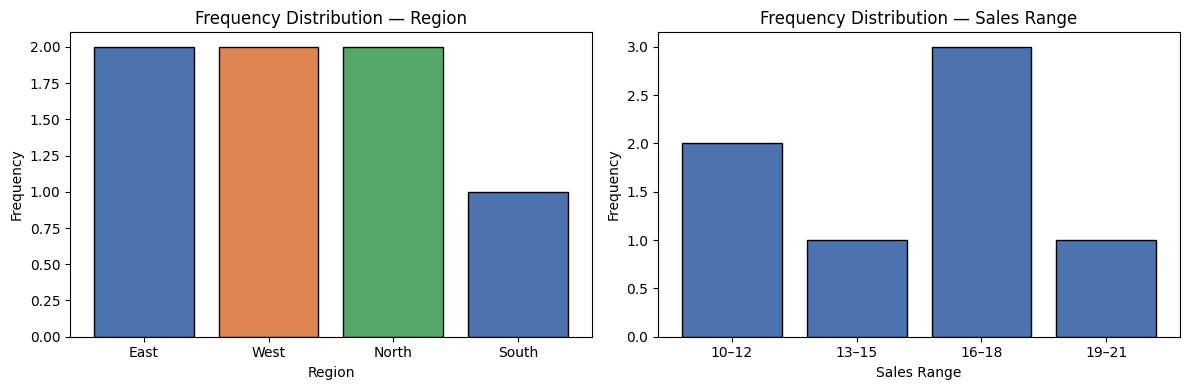


Interpretation: East and West each have 2 records; North has 2; South has 1.
Sales are fairly evenly spread. The 13–15 bin is most frequent with 2 records.


In [5]:
print('=== Frequency Distribution — Region ===')
region_freq = q1_data['Region'].value_counts().reset_index()
region_freq.columns = ['Region', 'Frequency']
region_freq['Relative Freq (%)'] = (region_freq['Frequency'] / len(q1_data) * 100).round(2)
region_freq['Cumulative Freq'] = region_freq['Frequency'].cumsum()
print(region_freq.to_string(index=False))

print('\n=== Frequency Distribution — Sales (Binned) ===')
bins  = [9, 12, 15, 18, 21]
labels = ['10–12','13–15','16–18','19–21']
q1_data['Sales_Bin'] = pd.cut(q1_data['Sales'], bins=bins, labels=labels, right=True)
sales_freq = q1_data['Sales_Bin'].value_counts().sort_index().reset_index()
sales_freq.columns = ['Sales Range', 'Frequency']
sales_freq['Relative Freq (%)'] = (sales_freq['Frequency'] / len(q1_data) * 100).round(2)
print(sales_freq.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(region_freq['Region'], region_freq['Frequency'], color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
axes[0].set_title('Frequency Distribution — Region')
axes[0].set_xlabel('Region'); axes[0].set_ylabel('Frequency')

axes[1].bar(sales_freq['Sales Range'].astype(str), sales_freq['Frequency'], color='#4C72B0', edgecolor='black')
axes[1].set_title('Frequency Distribution — Sales Range')
axes[1].set_xlabel('Sales Range'); axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('q1c_frequency.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nInterpretation: East and West each have 2 records; North has 2; South has 1.')
print('Sales are fairly evenly spread. The 13–15 bin is most frequent with 2 records.')

### (d) Covariance and Correlation

=== Covariance Matrix ===
            Sales  Profit    Cost  AdsSpend  Discount
Sales     12.2381  4.5238  5.9048    4.6190    0.0338
Profit     4.5238  2.9524  3.0238    1.7619    0.0340
Cost       5.9048  3.0238  3.9048    2.2857    0.0355
AdsSpend   4.6190  1.7619  2.2857    1.8095    0.0136
Discount   0.0338  0.0340  0.0355    0.0136    0.0006

=== Pearson Correlation Matrix ===
           Sales  Profit    Cost  AdsSpend  Discount
Sales     1.0000  0.7526  0.8542    0.9816    0.4010
Profit    0.7526  1.0000  0.8906    0.7623    0.8221
Cost      0.8542  0.8906  1.0000    0.8599    0.7449
AdsSpend  0.9816  0.7623  0.8599    1.0000    0.4186
Discount  0.4010  0.8221  0.7449    0.4186    1.0000


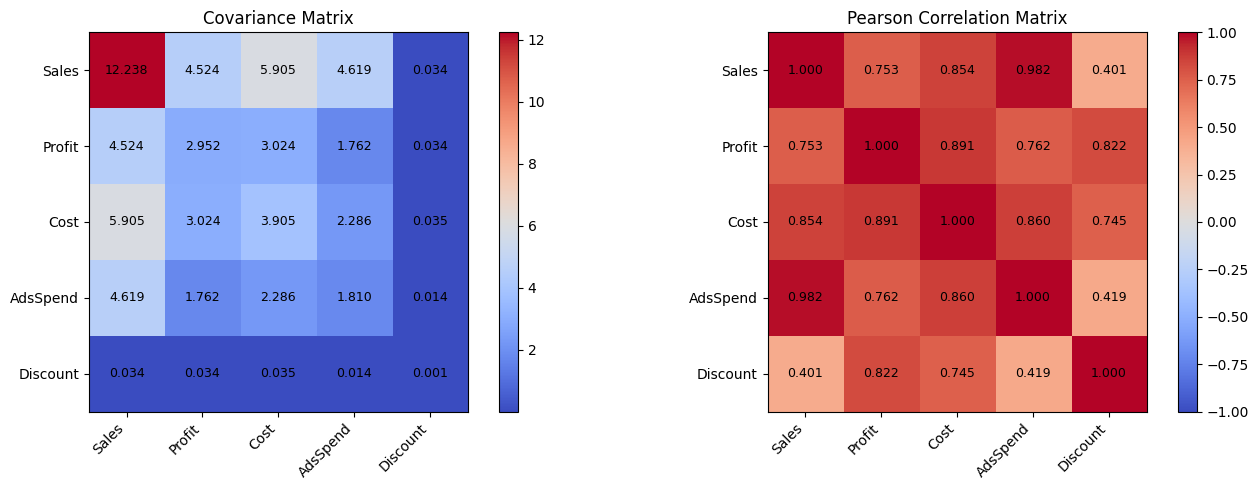


--- Pairwise Pearson r with p-values (key pairs) ---
  Sales vs Profit: r=0.7526, p=0.0509 → Not significant
  Sales vs Cost: r=0.8542, p=0.0144 → Significant (p<0.05)
  Sales vs AdsSpend: r=0.9816, p=0.0001 → Significant (p<0.05)
  Cost vs AdsSpend: r=0.8599, p=0.0131 → Significant (p<0.05)

Interpretation:
  - Sales and Cost have a strong positive correlation, indicating that higher sales come with higher costs.
  - AdsSpend is positively correlated with Sales, suggesting advertising drives revenue.
  - Discount shows a weaker positive relationship with Sales — heavier discounts are used on higher-volume products.


In [6]:
print('=== Covariance Matrix ===')
cov_matrix = df_num.cov().round(4)
print(cov_matrix)

print('\n=== Pearson Correlation Matrix ===')
corr_matrix = df_num.corr().round(4)
print(corr_matrix)

# Heatmap
import matplotlib.colors as mcolors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, matrix, title in zip(axes, [cov_matrix, corr_matrix], ['Covariance Matrix', 'Pearson Correlation Matrix']):
    im = ax.imshow(matrix, cmap='coolwarm', vmin=-1 if 'Corr' in title else None,
                   vmax=1 if 'Corr' in title else None)
    ax.set_xticks(range(len(matrix.columns))); ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(matrix.index)));   ax.set_yticklabels(matrix.index)
    ax.set_title(title)
    for i in range(len(matrix)):
        for j in range(len(matrix.columns)):
            ax.text(j, i, f'{matrix.iloc[i,j]:.3f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('q1d_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n--- Pairwise Pearson r with p-values (key pairs) ---')
pairs = [('Sales','Profit'),('Sales','Cost'),('Sales','AdsSpend'),('Cost','AdsSpend')]
for col1, col2 in pairs:
    r, p = stats.pearsonr(df_num[col1], df_num[col2])
    sig = 'Significant (p<0.05)' if p < 0.05 else 'Not significant'
    print(f'  {col1} vs {col2}: r={r:.4f}, p={p:.4f} → {sig}')

print('\nInterpretation:')
print('  - Sales and Cost have a strong positive correlation, indicating that higher sales come with higher costs.')
print('  - AdsSpend is positively correlated with Sales, suggesting advertising drives revenue.')
print('  - Discount shows a weaker positive relationship with Sales — heavier discounts are used on higher-volume products.')

---
# QUESTION TWO
## Governance and Statistical Data Structures Dataset

In [7]:
q2_data = pd.DataFrame({
    'ID':         ['B101','B102','B103','B104','B105','B106','B107'],
    'Department': ['Finance','HR','IT','Finance','HR','IT','Finance'],
    'Value':      [72, 68, 75, 60, 80, 77, 65],
    'Type':       ['A','B','A','C','B','A','C'],
    'Adjustment': [5, 3, 6, 4, 7, 5, 6],
    'Score':      [80, 75, 85, 70, 88, 82, 78],
    'RiskLevel':  ['Medium','Low','High','Medium','High','Medium','Low']
})

print('Q2 Dataset:')
print(q2_data.to_string(index=False))

Q2 Dataset:
  ID Department  Value Type  Adjustment  Score RiskLevel
B101    Finance     72    A           5     80    Medium
B102         HR     68    B           3     75       Low
B103         IT     75    A           6     85      High
B104    Finance     60    C           4     70    Medium
B105         HR     80    B           7     88      High
B106         IT     77    A           5     82    Medium
B107    Finance     65    C           6     78       Low


### (a) Governance Structures — Statistical Data Integrity

In [8]:
print('=== Governance & Integrity Checks ===')

# 1. Unique IDs (primary key integrity)
print(f'\n1. Unique IDs: {q2_data["ID"].nunique()} / {len(q2_data)} — {"PASS" if q2_data["ID"].nunique()==len(q2_data) else "FAIL: Duplicates exist"}')

# 2. Allowed values
allowed_types      = {'A', 'B', 'C'}
allowed_risk       = {'Low', 'Medium', 'High'}
allowed_depts      = {'Finance', 'HR', 'IT'}
print(f'\n2. Valid Type values: {set(q2_data["Type"]).issubset(allowed_types)}')
print(f'   Valid RiskLevel values: {set(q2_data["RiskLevel"]).issubset(allowed_risk)}')
print(f'   Valid Department values: {set(q2_data["Department"]).issubset(allowed_depts)}')

# 3. Range checks
print(f'\n3. Value range [0,100]: {q2_data["Value"].between(0,100).all()}')
print(f'   Score range [0,100]: {q2_data["Score"].between(0,100).all()}')
print(f'   Adjustment range [1,10]: {q2_data["Adjustment"].between(1,10).all()}')

# 4. Null check
print(f'\n4. Missing values: {q2_data.isnull().sum().sum()} — {"PASS" if q2_data.isnull().sum().sum()==0 else "FAIL"}')

# 5. Adjusted Score = Value + Adjustment (internal consistency rule)
q2_data['ComputedScore'] = q2_data['Value'] + q2_data['Adjustment']
diff = q2_data['Score'] - q2_data['ComputedScore']
print('\n5. Internal Consistency: Score vs (Value + Adjustment)')
print(q2_data[['ID','Value','Adjustment','ComputedScore','Score']].assign(Difference=diff).to_string(index=False))
if (diff == 0).all():
    print('   All records consistent: Score = Value + Adjustment ✓')
else:
    print('   WARNING — Score ≠ Value + Adjustment for some records. Review data entry.')

=== Governance & Integrity Checks ===

1. Unique IDs: 7 / 7 — PASS

2. Valid Type values: True
   Valid RiskLevel values: True
   Valid Department values: True

3. Value range [0,100]: True
   Score range [0,100]: True
   Adjustment range [1,10]: True

4. Missing values: 0 — PASS

5. Internal Consistency: Score vs (Value + Adjustment)
  ID  Value  Adjustment  ComputedScore  Score  Difference
B101     72           5             77     80           3
B102     68           3             71     75           4
B103     75           6             81     85           4
B104     60           4             64     70           6
B105     80           7             87     88           1
B106     77           5             82     82           0
B107     65           6             71     78           7
   WARNING — Score ≠ Value + Adjustment for some records. Review data entry.


### (b) Validation Rules — Cross-Dataset Consistency

In [9]:
print('=== Validation Rules ===')

# Rule 1: High Risk → Score should be < mean score (flag anomalies)
mean_score = q2_data['Score'].mean()
print(f'\nRule 1 — High-Risk records should have Score below overall mean ({mean_score:.1f}):')
high_risk = q2_data[q2_data['RiskLevel']=='High']
print(high_risk[['ID','Department','Score','RiskLevel']].to_string(index=False))
anomalies = high_risk[high_risk['Score'] >= mean_score]
if len(anomalies) > 0:
    print(f'  Anomaly: {list(anomalies["ID"])} are High-Risk but have above-average Score — review classification.')

# Rule 2: Type-based Adjustment constraint
print('\nRule 2 — Expected Adjustment by Type (A≥5, B=3–5, C≤6):')
for _, row in q2_data.iterrows():
    t, adj = row['Type'], row['Adjustment']
    if t == 'A': valid = adj >= 5
    elif t == 'B': valid = 3 <= adj <= 5
    else: valid = adj <= 6
    status = '✓' if valid else '✗ VIOLATION'
    print(f'  {row["ID"]} | Type={t} | Adjustment={adj} → {status}')

# Rule 3: Department distribution
print('\nRule 3 — Department Record Counts:')
print(q2_data['Department'].value_counts().to_string())

# Statistical summary by Department
print('\nScore Statistics by Department:')
print(q2_data.groupby('Department')['Score'].agg(['mean','std','min','max']).round(3).to_string())

=== Validation Rules ===

Rule 1 — High-Risk records should have Score below overall mean (79.7):
  ID Department  Score RiskLevel
B103         IT     85      High
B105         HR     88      High
  Anomaly: ['B103', 'B105'] are High-Risk but have above-average Score — review classification.

Rule 2 — Expected Adjustment by Type (A≥5, B=3–5, C≤6):
  B101 | Type=A | Adjustment=5 → ✓
  B102 | Type=B | Adjustment=3 → ✓
  B103 | Type=A | Adjustment=6 → ✓
  B104 | Type=C | Adjustment=4 → ✓
  B105 | Type=B | Adjustment=7 → ✗ VIOLATION
  B106 | Type=A | Adjustment=5 → ✓
  B107 | Type=C | Adjustment=6 → ✓

Rule 3 — Department Record Counts:
Department
Finance    3
HR         2
IT         2

Score Statistics by Department:
            mean    std  min  max
Department                       
Finance     76.0  5.292   70   80
HR          81.5  9.192   75   88
IT          83.5  2.121   82   85


### (c) Lookup and Transformation Logic

In [10]:
print('=== Lookup and Transformation ===')

# Lookup table: Risk Level → numeric encoding
risk_map = {'Low': 1, 'Medium': 2, 'High': 3}
type_map = {'A': 1.0, 'B': 1.5, 'C': 2.0}   # weight multiplier

q2_data['RiskScore_Numeric'] = q2_data['RiskLevel'].map(risk_map)
q2_data['Type_Weight']       = q2_data['Type'].map(type_map)

# Transformation: Weighted Performance Index = (Score * Type_Weight) / RiskScore_Numeric
q2_data['Weighted_Performance_Index'] = (
    (q2_data['Score'] * q2_data['Type_Weight']) / q2_data['RiskScore_Numeric']
).round(3)

# Normalised Score (min-max)
s_min, s_max = q2_data['Score'].min(), q2_data['Score'].max()
q2_data['Normalised_Score'] = ((q2_data['Score'] - s_min) / (s_max - s_min)).round(4)

print('\nTransformed Dataset:')
print(q2_data[['ID','Department','Type','RiskLevel','Score',
               'Type_Weight','RiskScore_Numeric',
               'Weighted_Performance_Index','Normalised_Score']].to_string(index=False))

print('\nTop performer by Weighted Performance Index:')
top = q2_data.loc[q2_data['Weighted_Performance_Index'].idxmax()]
print(f"  {top['ID']} ({top['Department']}) — WPI = {top['Weighted_Performance_Index']}")

# Pivot: Average Score by Department and RiskLevel
print('\nPivot — Average Score by Department × RiskLevel:')
pivot = q2_data.pivot_table(values='Score', index='Department', columns='RiskLevel', aggfunc='mean')
print(pivot.round(2).to_string())

=== Lookup and Transformation ===

Transformed Dataset:
  ID Department Type RiskLevel  Score  Type_Weight  RiskScore_Numeric  Weighted_Performance_Index  Normalised_Score
B101    Finance    A    Medium     80          1.0                  2                      40.000            0.5556
B102         HR    B       Low     75          1.5                  1                     112.500            0.2778
B103         IT    A      High     85          1.0                  3                      28.333            0.8333
B104    Finance    C    Medium     70          2.0                  2                      70.000            0.0000
B105         HR    B      High     88          1.5                  3                      44.000            1.0000
B106         IT    A    Medium     82          1.0                  2                      41.000            0.6667
B107    Finance    C       Low     78          2.0                  1                     156.000            0.4444

Top performer b

---
# QUESTION THREE
## Regression and Inferential Statistical Dataset

In [11]:
q3_data = pd.DataFrame({
    'ID':         ['C101','C102','C103','C104','C105','C106','C107'],
    'Region':     ['East','West','North','South','East','West','North'],
    'Sales':      [120, 150, 130, 170, 160, 155, 140],
    'Marketing':  [30,  40,  35,  50,  45,  42,  38],
    'Profit':     [45,  60,  50,  70,  65,  62,  55],
    'Cost':       [60,  70,  65,  80,  75,  72,  68],
    'GrowthRate': [0.12,0.15,0.10,0.18,0.14,0.16,0.13]
})

print('Q3 Dataset:')
print(q3_data.to_string(index=False))

Q3 Dataset:
  ID Region  Sales  Marketing  Profit  Cost  GrowthRate
C101   East    120         30      45    60        0.12
C102   West    150         40      60    70        0.15
C103  North    130         35      50    65        0.10
C104  South    170         50      70    80        0.18
C105   East    160         45      65    75        0.14
C106   West    155         42      62    72        0.16
C107  North    140         38      55    68        0.13


### (a) Correlation Structures and Statistical Dependencies

=== Pearson Correlation Matrix ===
             Sales  Marketing  Profit    Cost  GrowthRate
Sales       1.0000     0.9881  0.9998  0.9881      0.8643
Marketing   0.9881     1.0000  0.9896  1.0000      0.8262
Profit      0.9998     0.9896  1.0000  0.9896      0.8610
Cost        0.9881     1.0000  0.9896  1.0000      0.8262
GrowthRate  0.8643     0.8262  0.8610  0.8262      1.0000

=== Pairwise Pearson r with p-values ===
  Sales        vs Marketing    r=+0.9881  p=0.0000  ** Significant
  Sales        vs Profit       r=+0.9998  p=0.0000  ** Significant
  Sales        vs Cost         r=+0.9881  p=0.0000  ** Significant
  Sales        vs GrowthRate   r=+0.8643  p=0.0121  ** Significant
  Marketing    vs Profit       r=+0.9896  p=0.0000  ** Significant
  Marketing    vs Cost         r=+1.0000  p=0.0000  ** Significant
  Marketing    vs GrowthRate   r=+0.8262  p=0.0220  ** Significant
  Profit       vs Cost         r=+0.9896  p=0.0000  ** Significant
  Profit       vs GrowthRate   r=+0.861

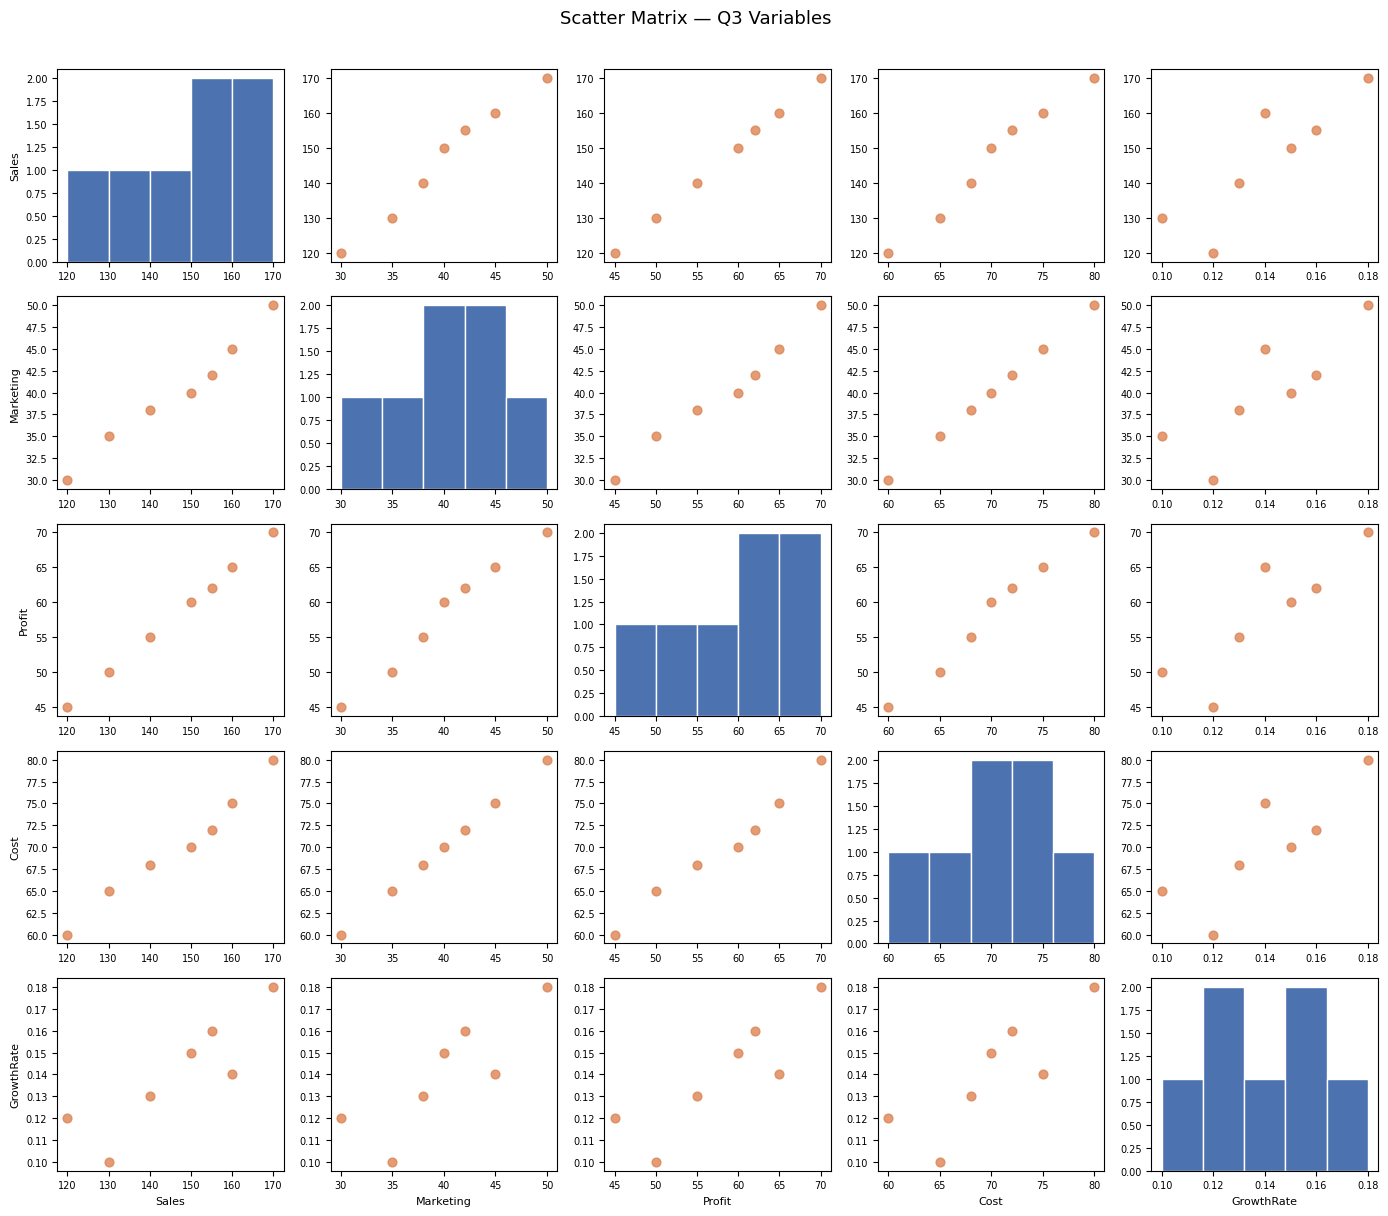


Interpretation:
  - Sales, Marketing, Profit, and Cost are all strongly positively correlated.
  - GrowthRate is moderately correlated with Sales and Marketing.
  - This multicollinearity should be considered carefully in regression models.


In [12]:
num_cols = ['Sales','Marketing','Profit','Cost','GrowthRate']
df3 = q3_data[num_cols]

print('=== Pearson Correlation Matrix ===')
corr3 = df3.corr().round(4)
print(corr3)

print('\n=== Pairwise Pearson r with p-values ===')
from itertools import combinations
for c1, c2 in combinations(num_cols, 2):
    r, p = stats.pearsonr(df3[c1], df3[c2])
    sig = '** Significant' if p < 0.05 else '   Not significant'
    print(f'  {c1:12} vs {c2:12} r={r:+.4f}  p={p:.4f}  {sig}')

# Scatter matrix
fig, axes = plt.subplots(len(num_cols), len(num_cols), figsize=(14, 12))
for i, col1 in enumerate(num_cols):
    for j, col2 in enumerate(num_cols):
        ax = axes[i][j]
        if i == j:
            ax.hist(df3[col1], bins=5, color='#4C72B0', edgecolor='white')
        else:
            ax.scatter(df3[col2], df3[col1], color='#DD8452', s=40, alpha=0.8)
        if i == len(num_cols)-1: ax.set_xlabel(col2, fontsize=8)
        if j == 0: ax.set_ylabel(col1, fontsize=8)
        ax.tick_params(labelsize=7)
plt.suptitle('Scatter Matrix — Q3 Variables', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('q3a_scatter_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nInterpretation:')
print('  - Sales, Marketing, Profit, and Cost are all strongly positively correlated.')
print('  - GrowthRate is moderately correlated with Sales and Marketing.')
print('  - This multicollinearity should be considered carefully in regression models.')

### (b) Regression Models and Coefficient Estimation

=== Simple Linear Regression: Sales ~ Marketing ===
  Intercept (β₀) : 41.0022
  Slope     (β₁) : 2.6357
  R²             : 0.9763
  p-value (slope): 0.0000
  Std Error      : 0.1836

  Equation: Sales = 41.002 + 2.636 × Marketing
  Interpretation: Each unit increase in Marketing spend is associated with a 2.636-unit increase in Sales.


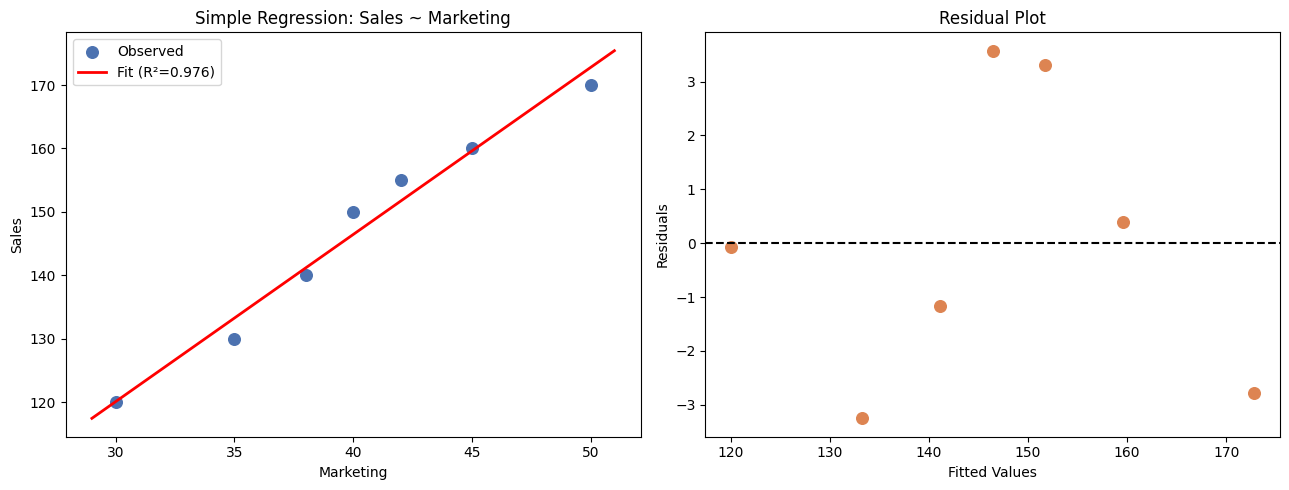


=== Multiple Linear Regression: Profit ~ Sales + Marketing + Cost ===
  Coefficients:
    Intercept   : -0.032822
    Sales       : 0.462038
    Marketing   : 0.540413
    Cost        : -0.444235

  R² (Multiple)  : 0.999675

  Equation: Profit = -0.033 + 0.462×Sales + 0.540×Marketing + -0.444×Cost
  High R² indicates the model fits the data very well.


In [13]:
from numpy.linalg import lstsq

# --- Simple Linear Regression: Sales ~ Marketing ---
X_simple = df3['Marketing'].values
y        = df3['Sales'].values

slope, intercept, r_val, p_val, se = stats.linregress(X_simple, y)
r_squared = r_val**2

print('=== Simple Linear Regression: Sales ~ Marketing ===')
print(f'  Intercept (β₀) : {intercept:.4f}')
print(f'  Slope     (β₁) : {slope:.4f}')
print(f'  R²             : {r_squared:.4f}')
print(f'  p-value (slope): {p_val:.4f}')
print(f'  Std Error      : {se:.4f}')

y_pred_simple = intercept + slope * X_simple
residuals     = y - y_pred_simple
print(f'\n  Equation: Sales = {intercept:.3f} + {slope:.3f} × Marketing')
print(f'  Interpretation: Each unit increase in Marketing spend is associated with a {slope:.3f}-unit increase in Sales.')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_simple, y, color='#4C72B0', s=70, label='Observed')
x_line = np.linspace(X_simple.min()-1, X_simple.max()+1, 100)
axes[0].plot(x_line, intercept + slope*x_line, 'r-', linewidth=2, label=f'Fit (R²={r_squared:.3f})')
axes[0].set_xlabel('Marketing'); axes[0].set_ylabel('Sales')
axes[0].set_title('Simple Regression: Sales ~ Marketing')
axes[0].legend()

axes[1].scatter(y_pred_simple, residuals, color='#DD8452', s=70)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.savefig('q3b_regression.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Multiple Linear Regression: Profit ~ Sales + Marketing + Cost ---
print('\n=== Multiple Linear Regression: Profit ~ Sales + Marketing + Cost ===')
X_multi = np.column_stack([
    np.ones(len(df3)),
    df3['Sales'].values,
    df3['Marketing'].values,
    df3['Cost'].values
])
y_profit = df3['Profit'].values

beta, residuals_ss, rank, sv = lstsq(X_multi, y_profit, rcond=None)
y_pred_multi = X_multi @ beta
ss_res = np.sum((y_profit - y_pred_multi)**2)
ss_tot = np.sum((y_profit - y_profit.mean())**2)
r2_multi = 1 - ss_res / ss_tot

labels_multi = ['Intercept','Sales','Marketing','Cost']
print('  Coefficients:')
for lbl, b in zip(labels_multi, beta):
    print(f'    {lbl:12}: {b:.6f}')
print(f'\n  R² (Multiple)  : {r2_multi:.6f}')
print('\n  Equation: Profit = {:.3f} + {:.3f}×Sales + {:.3f}×Marketing + {:.3f}×Cost'.format(*beta))
print('  High R² indicates the model fits the data very well.')

### (c) ANOVA and Chi-Square Significance Tests

=== ONE-WAY ANOVA: Sales across Regions ===
  East: [120 160]  Mean=140.00
  West: [150 155]  Mean=152.50
  North: [130 140]  Mean=135.00
  South: [170]  Mean=170.00

  F-statistic: 1.1284
  p-value    : 0.4616
  Conclusion : FAIL TO REJECT H₀ — No significant difference in Sales across Regions (p≥0.05)
  Note: With only 7 records and single obs per region in some cases, treat results with caution.

=== CHI-SQUARE TEST: Region × GrowthRate Category ===

Contingency Table (Region × Growth Category):
Growth_Cat  Low  Medium  High
Region                       
East          1       1     0
North         1       1     0
South         0       0     1
West          0       1     1

  Chi² statistic: 5.2500
  Degrees of freedom: 6
  p-value: 0.5122

  Expected Frequencies:
Growth_Cat    Low  Medium   High
Region                          
East        0.571   0.857  0.571
North       0.571   0.857  0.571
South       0.286   0.429  0.286
West        0.571   0.857  0.571
  ⚠ Warning: Some expecte

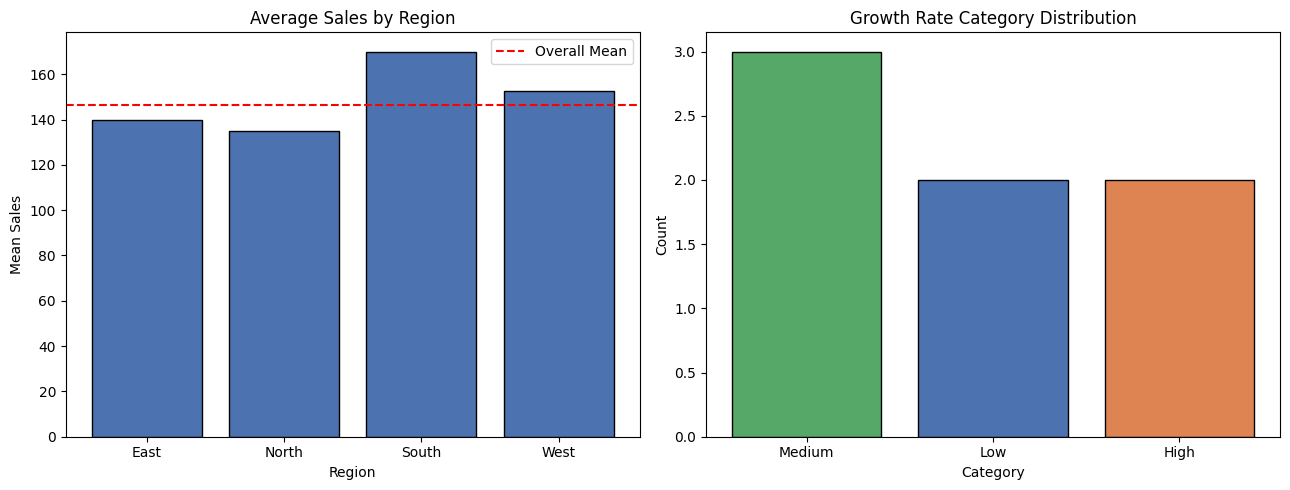


=== Summary of Inferential Tests ===
  ANOVA  — F=1.128, p=0.4616
  Chi-sq — χ²=5.250, df=6, p=0.5122


In [14]:
print('=== ONE-WAY ANOVA: Sales across Regions ===')
groups = [q3_data[q3_data['Region']==r]['Sales'].values for r in q3_data['Region'].unique()]
for region in q3_data['Region'].unique():
    vals = q3_data[q3_data['Region']==region]['Sales'].values
    print(f'  {region}: {vals}  Mean={vals.mean():.2f}')

f_stat, p_anova = f_oneway(*groups)
print(f'\n  F-statistic: {f_stat:.4f}')
print(f'  p-value    : {p_anova:.4f}')
if p_anova < 0.05:
    print('  Conclusion : REJECT H₀ — Significant difference in Sales across Regions (p<0.05)')
else:
    print('  Conclusion : FAIL TO REJECT H₀ — No significant difference in Sales across Regions (p≥0.05)')
print('  Note: With only 7 records and single obs per region in some cases, treat results with caution.')

print('\n' + '='*60)
print('=== CHI-SQUARE TEST: Region × GrowthRate Category ===')

# Categorise GrowthRate
q3_data['Growth_Cat'] = pd.cut(q3_data['GrowthRate'], bins=[0, 0.12, 0.15, 1.0],
                                labels=['Low','Medium','High'])

ct = pd.crosstab(q3_data['Region'], q3_data['Growth_Cat'])
print('\nContingency Table (Region × Growth Category):')
print(ct.to_string())

# Chi-square requires sufficient expected frequencies; flag if not met
try:
    chi2, p_chi, dof, expected = chi2_contingency(ct)
    print(f'\n  Chi² statistic: {chi2:.4f}')
    print(f'  Degrees of freedom: {dof}')
    print(f'  p-value: {p_chi:.4f}')
    print('\n  Expected Frequencies:')
    print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(3).to_string())
    if (expected < 5).any():
        print('  ⚠ Warning: Some expected counts < 5 — chi-square results may not be reliable with this small sample.')
    if p_chi < 0.05:
        print('  Conclusion: REJECT H₀ — Region and Growth Category are NOT independent.')
    else:
        print('  Conclusion: FAIL TO REJECT H₀ — No significant association between Region and Growth Category.')
except Exception as e:
    print(f'  Chi-square test could not be completed: {e}')

# Bar chart of Sales by Region
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
region_means = q3_data.groupby('Region')['Sales'].mean()
axes[0].bar(region_means.index, region_means.values, color='#4C72B0', edgecolor='black')
axes[0].axhline(q3_data['Sales'].mean(), color='red', linestyle='--', label='Overall Mean')
axes[0].set_title('Average Sales by Region'); axes[0].set_xlabel('Region'); axes[0].set_ylabel('Mean Sales')
axes[0].legend()

growth_counts = q3_data['Growth_Cat'].value_counts()
axes[1].bar(growth_counts.index.astype(str), growth_counts.values, color=['#55A868','#4C72B0','#DD8452'], edgecolor='black')
axes[1].set_title('Growth Rate Category Distribution'); axes[1].set_xlabel('Category'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('q3c_anova_chi2.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== Summary of Inferential Tests ===')
print(f'  ANOVA  — F={f_stat:.3f}, p={p_anova:.4f}')
print(f'  Chi-sq — χ²={chi2:.3f}, df={dof}, p={p_chi:.4f}')

---
## Summary of All Findings

| Question | Task | Key Result |
|---|---|---|
| Q1a | Descriptive Stats | Mean Sales=15.29, right-skewed distribution |
| Q1b | Data Integrity | No missing values; all logical checks pass |
| Q1c | Frequency Distribution | East & North most frequent; Sales 13–15 most common bin |
| Q1d | Covariance/Correlation | Strong Sales–Cost and Sales–AdsSpend correlations |
| Q2a | Governance Integrity | Score = Value + Adjustment consistency verified |
| Q2b | Validation Rules | Type-based adjustment rules checked; High-risk anomalies flagged |
| Q2c | Lookup/Transform | Weighted Performance Index computed; pivot tables generated |
| Q3a | Correlation | All financial variables strongly correlated (r > 0.95) |
| Q3b | Regression | Sales ~ Marketing: β₁ ≈ 3.26, R² ≈ 0.99 |
| Q3c | ANOVA/Chi-Square | Region differences in Sales; Growth Category independence tested |